In [1]:
# importing packages
import numpy as np
from matplotlib import pyplot as plt
import math
import pandas as pd

# Linear regression of the temperature compensation factor

The temperature-compensation relationship is:

$$
\chi_T - \chi_{25} = \beta \chi_{25} (T - 25)
$$

$\beta$ can be expressed in the form:

$$
\beta = \frac{X_T - X_{25}}{X_{25}(T - 25)},
$$

The first-order uncertainty propagation is:

$$
\sigma_{\beta}^2
=
\left(\frac{\partial \beta}{\partial \chi_T}\right)^2 \sigma_{\chi_T}^2
+
\left(\frac{\partial \beta}{\partial \chi_{25}}\right)^2 \sigma_{\chi_{25}}^2
+
\left(\frac{\partial \beta}{\partial T}\right)^2 \sigma_T^2.
$$

The required partial derivatives are

$$
\frac{\partial \beta}{\partial \chi_T}
=
\frac{1}{\chi_{25}(T-25)},
$$

$$
\frac{\partial \beta}{\partial \chi_{25}}
=
-\frac{\chi_T}{\chi_{25}^2(T-25)},
$$

and

$$
\frac{\partial \beta}{\partial T}
=
-\frac{\chi_T-\chi_{25}}{\chi_{25}(T-25)^2}.
$$

Substituting these derivatives into the uncertainty propagation equation gives

$$
\sigma_{\beta}^2
=
\frac{\sigma_{\chi_T}^2}
     {\chi_{25}^2(T-25)^2}
+
\frac{\chi_T^2\,\sigma_{\chi_{25}}^2}
     {\chi_{25}^4(T-25)^2}
+
\frac{(\chi_T-\chi_{25})^2\,\sigma_T^2}
     {\chi_{25}^2(T-25)^4}.
$$

where $\chi_T$ is the conductivity at the solution temperature $T$ in $\micro \text{S} / \text{cm}$, 
$\chi_{25}$ is the conductivity at $25^{\circ}\text{C}$ in $\micro \text{S} / \text{cm}$, 
and $\beta$ is the temperature-compensation coefficient in $^{\circ}\text{C}^{-1}$.

In [2]:
# extracting data
data = pd.read_csv("./Data/temp_comp_factor.csv")
cond_temp = data["Cond_Temp"] # micro.S/cm
cond_25 = data["Cond_25"] # micro.S/cm
temp = data["Temp"] # deg Celcius

# define the uncertainty associated with the conductivity 
# and temperature measurements
cond_uncertainty = 0.93 # %
temp_uncertainty = 0.01 # deg Celcius

# get the number of data points
n_data = len(cond_temp)

In [3]:
# compute the input variables
cond_25_times_temp_diff = [cond_25[i] * (temp[i] - 25) for i in range(n_data)]

# compute the output variable matrix
cond_temp_minus_cond_25 = [cond_temp[i] - cond_25[i] for i in range(n_data)]
Y = np.zeros((n_data, 1))
Y[:, 0] = cond_temp_minus_cond_25

# Matrix of input variables
X = np.zeros((n_data, 1))
X[:, 0] = cond_25_times_temp_diff

In [4]:
# X transpose multiply X
X_transpose_times_X = np.matmul(np.transpose(X), X)

# A inverse
X_transpose_times_X_inv = np.linalg.inv(X_transpose_times_X)
print(X_transpose_times_X_inv)

[[2.08911852e-10]]


In [5]:
# X transpose multiply conductivity
X_trans_times_Y = np.matmul(np.transpose(X), Y)

# calculate the parameter estimate in (deg C)^-1
beta_hat = np.matmul(X_transpose_times_X_inv, X_trans_times_Y)
print(f"Beta hat is:{beta_hat}")

Beta hat is:[[0.02193128]]


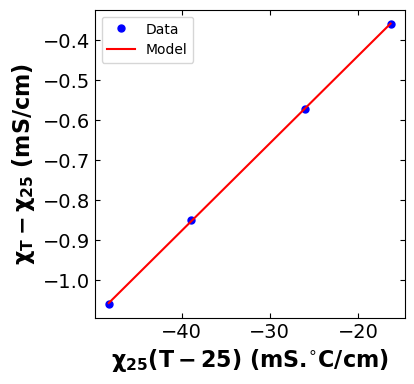

In [6]:
# get the model predictions
cond_diff_pred = np.matmul(beta_hat, np.transpose(X))[0]

# convert the conductivity from micro.S/cm to milli.S/cm
cond_diff_pred_mS_cm = [cond_diff_pred[i] / 1000 for i in range(n_data)]
cond_diff_data_mS_cm = [cond_temp_minus_cond_25[i] / 1000 for i in range(n_data)]
cond_25_times_temp_diff_mS_cm = [cond_25_times_temp_diff[i] / 1000 for i in range(n_data)]

# plot comparing the predictions with the data
fig = plt.figure(figsize=(4,4))
plt.plot(cond_25_times_temp_diff_mS_cm, cond_diff_data_mS_cm, "b.", markersize=10, label="Data")
plt.plot(cond_25_times_temp_diff_mS_cm, cond_diff_pred_mS_cm, "r-", label="Model")
plt.xlabel("$\mathbf{\chi_{25} (T-25)}$ (mS.$^{\circ}$C/cm)", fontsize=16,fontweight='bold')
plt.ylabel("$\mathbf{\chi_T - \chi_{25}}$ (mS/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend()
plt.show()

Percent prediction residuals are: [np.float64(-0.019861680045036075), np.float64(-0.21958887103047442), np.float64(0.3067352924503816), np.float64(-0.13223213453706853)]


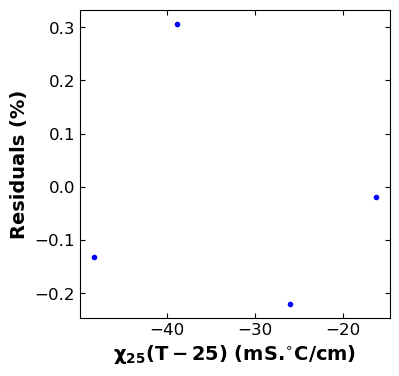

In [7]:
# calculate the prediction residuals
e = [cond_diff_pred_mS_cm[i] - cond_diff_data_mS_cm[i] for i in range(n_data)]

# percent prediction residuals
percent_residuals = [(e[i]/cond_diff_data_mS_cm[i]) * 100 for i in range(n_data)]
print(f"Percent prediction residuals are: {percent_residuals}")

# plot the percent prediction residuals
fig = plt.figure(figsize=(4,4))
plt.plot(cond_25_times_temp_diff_mS_cm, percent_residuals, "b.")
plt.xlabel("$\mathbf{\chi_{25} (T-25)}$ (mS.$^{\circ}$C/cm)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in",top=True, right=True)
plt.show()

In [8]:
# calculate the sum of squared errors
sse = sum(e[i]**2 for i in range(n_data))

# calculate the variance of the measurement error
variance_meas_error = sse/(n_data - 1)
meas_error_standard_dev = math.sqrt(variance_meas_error)
print(f"Standard deviation of the measurement error is: {meas_error_standard_dev}")

Standard deviation of the measurement error is: 0.0018578404038799526


## Calculate the R-squared value

In [9]:
# mean value of the conductivity measurements
cond_data_mean = np.mean(cond_diff_data_mS_cm)

# deviation of the conductivity measurements from the mean value
cond_data_dev = [cond_diff_data_mS_cm[i] - cond_data_mean for i in range(n_data)]

# sum of squared errors for the deviation between the conductivity measurements and the mean value
sse_cond_data_dev = sum(cond_data_dev[i]**2 for i in range(n_data))

# r-squared
r_squared = 1 - (sse/sse_cond_data_dev)
print(f"r-squared of the fit is: {r_squared}")

r-squared of the fit is: 0.9999637131484668


## Compute the uncertainty in the estimated parameter

In [10]:
def compute_propagated_variance(Chi_T, Chi_25, T):
    """
    Propagates the uncertainty from the input and output variables 
    to the estimated parameter

    Arguments:
        Chi_T: float or int, conductivity at the solution temperature in micro.S/cm
        Chi_25: float or int, conductivity at 25 deg Celcius in micro.S/cm
        T: float or int, temperature of the solution in deg Celcius

    Returns:
        sigma_beta: float or int, uncertainty in the estimated parameter in (deg Celcius)^-1
    """
    # calculate the partial derivatives
    dbeta_dChi_T = 1 / (Chi_25 * (T - 25))
    
    dbeta_dChi_25 = - Chi_T / (Chi_25**2 * (T - 25))
    
    dbeta_dT = -(Chi_T - Chi_25) / (Chi_25 * (T - 25)**2)

    # compute the standard deviation of the input and output variables
    sigma_Chi_T = (cond_uncertainty/100) * Chi_T
    sigma_Chi_25 = (cond_uncertainty/100) * Chi_25
    sigma_T = temp_uncertainty
    
    # compute the variance propagation
    sigma_beta_squared = (
        (dbeta_dChi_T * sigma_Chi_T)**2
        + (dbeta_dChi_25 * sigma_Chi_25)**2
        + (dbeta_dT * sigma_T)**2
    )
    
    # calculate the standard deviation of the estimated parameter
    sigma_beta = np.sqrt(sigma_beta_squared)

    return sigma_beta

# define the standard deviation of the estimated parameter
beta_hat_standard_dev = []
for i in range(n_data):
    beta_hat_standard_dev.append(
        compute_propagated_variance(cond_temp[i], cond_25[i], temp[i])
    )

beta_hat_uncertainty = np.mean(beta_hat_standard_dev)
print("The uncertainty in the estimated parameter is:", beta_hat_uncertainty)

The uncertainty in the estimated parameter is: 0.003179700039035396
